<a href="https://colab.research.google.com/github/Dhamodharan2006/Bi-Model-Approach-for-feature-extraction-from-Sensor-data-for-HAV/blob/main/PlantDocBot(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
import glob
import pathlib
import random

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

# Base paths
BASE_DIR = pathlib.Path("/content/PlantDocBot")
DATA_DIR = BASE_DIR / "data"
PLANT_VILLAGE_DIR = DATA_DIR / "plantvillage"
PLANT_DOC_DIR = DATA_DIR / "plantdoc"

# Create required folders
for d in [PLANT_VILLAGE_DIR, PLANT_DOC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"✅ Project structure created at: {BASE_DIR}")


✅ Project structure created at: /content/PlantDocBot


In [2]:
# Section 2: Data Acquisition

def clone_repo(repo_url: str, target_dir: pathlib.Path):
    """Clone a Git repo into target_dir if directory is empty."""
    if any(target_dir.iterdir()):
        print(f"ℹ️ Data already exists in {target_dir}, skipping clone.")
        return
    print(f"⬇️ Cloning {repo_url} ...")
    os.system(f"git clone {repo_url} {target_dir}")
    print(f"✅ Cloned into {target_dir}")

# PlantVillage (classification)
clone_repo(
    "https://github.com/spMohanty/plantvillage-Dataset.git",
    PLANT_VILLAGE_DIR,
)

# PlantDoc (noisy real-world)
clone_repo(
    "https://github.com/pratikkayal/PlantDoc-Dataset.git",
    PLANT_DOC_DIR,
)


⬇️ Cloning https://github.com/spMohanty/plantvillage-Dataset.git ...
✅ Cloned into /content/PlantDocBot/data/plantvillage
⬇️ Cloning https://github.com/pratikkayal/PlantDoc-Dataset.git ...
✅ Cloned into /content/PlantDocBot/data/plantdoc


In [4]:
# Section 3: Data Verification

def list_contents(directory: pathlib.Path, name: str, limit: int = 5):
    """Print first few items in a directory."""
    try:
        items = sorted(p.name for p in directory.iterdir())
        print(f"\n📂 Contents of {name} ({len(items)} items):")
        print(items[:limit], "...")
    except Exception as e:
        print(f"❌ Error reading {name}: {e}")

list_contents(PLANT_VILLAGE_DIR, "PlantVillage")
list_contents(PLANT_DOC_DIR, "PlantDoc")



📂 Contents of PlantVillage (46 items):
['.git', '.gitignore', 'README.md', '_generate_data.sh', 'create_data_distribution.py'] ...

📂 Contents of PlantDoc (6 items):
['.git', 'LICENSE.txt', 'PlantDoc_Examples.png', 'README.md', 'test'] ...


In [5]:
#  Section 4: Exploratory Data Analysis (EDA)

def analyze_dataset(base_path: pathlib.Path, dataset_name: str):
    """Count how many images are present in each leaf-class folder."""
    img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    class_counts = {}

    print(f"\n🔎 Analyzing {dataset_name} ...")

    for root, _, files in os.walk(base_path):
        images = [f for f in files if pathlib.Path(f).suffix.lower() in img_exts]
        if not images:
            continue
        class_name = pathlib.Path(root).name
        class_counts[class_name] = len(images)

    if not class_counts:
        print(f"⚠️ No image directories found in {dataset_name}.")
        return None

    total_images = sum(class_counts.values())
    print(f"✅ Found {len(class_counts)} classes.")
    print(f"   Total Images: {total_images}")
    print("   Top 5 classes:")
    for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"   - {cls}: {count} images")

    return class_counts

pv_stats = analyze_dataset(PLANT_VILLAGE_DIR, "PlantVillage")
pd_stats = analyze_dataset(PLANT_DOC_DIR, "PlantDoc")



🔎 Analyzing PlantVillage ...
✅ Found 76 classes.
   Total Images: 64853
   Top 5 classes:
   - Orange___Haunglongbing_(Citrus_greening): 5507 images
   - Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 images
   - Soybean___healthy: 5090 images
   - Peach___Bacterial_spot: 2297 images
   - Tomato___Bacterial_spot: 2127 images

🔎 Analyzing PlantDoc ...
✅ Found 29 classes.
   Total Images: 239
   Top 5 classes:
   - Corn leaf blight: 12 images
   - grape leaf: 12 images
   - Tomato Septoria leaf spot: 11 images
   - Blueberry leaf: 11 images
   - Corn rust leaf: 10 images


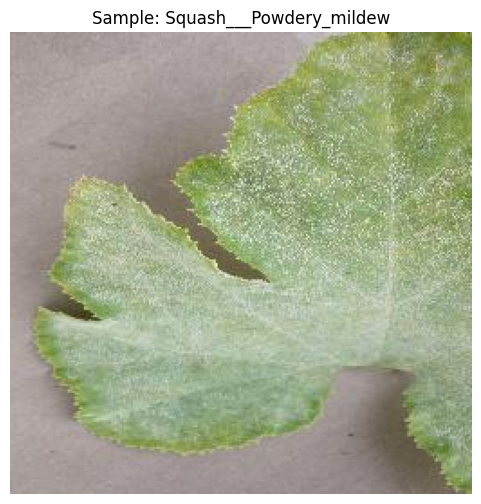

📷 Showing sample from: /content/PlantDocBot/data/plantvillage/raw/color/Squash___Powdery_mildew/8b35bf64-3045-46f6-afc9-842c51f7507a___MD_Powd.M 0142 copy.jpg


In [6]:
#  Section 5: One Sample Visualization

def show_sample_image(base_path: pathlib.Path):
    """Show one sample image from dataset to verify it loads."""
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    all_images = []
    for p in patterns:
        all_images.extend(glob.glob(str(base_path / "**" / p), recursive=True))

    if not all_images:
        print("❌ No images found to display.")
        return

    sample_path = all_images[0]
    img = mpimg.imread(sample_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Sample: {pathlib.Path(sample_path).parent.name}")
    plt.axis("off")
    plt.show()
    print(f"📷 Showing sample from: {sample_path}")

show_sample_image(PLANT_VILLAGE_DIR)


📷 Random image: /content/PlantDocBot/data/plantvillage/data_distribution_for_SVM/train/12/5569c094-607e-4d16-9ed3-511584bb0db4.JPG
   Original mode: RGB


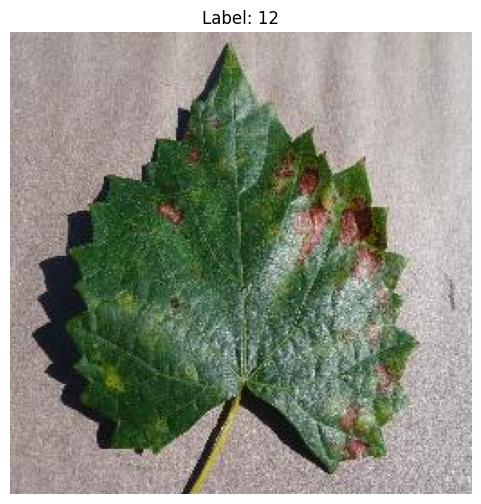

In [7]:
# Section 6: Robust RGB Random Display

def display_random_image(base_path: pathlib.Path):
    """Pick a random image, convert to RGB if needed, and display."""
    img_exts = (".jpg", ".jpeg", ".png", ".bmp")
    all_files = []

    for root, _, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(img_exts):
                all_files.append(os.path.join(root, f))

    if not all_files:
        print("❌ No images found.")
        return

    sample_file = random.choice(all_files)
    print(f"📷 Random image: {sample_file}")

    try:
        img = Image.open(sample_file)
        print(f"   Original mode: {img.mode}")

        if img.mode != "RGB":
            img = img.convert("RGB")
            print("   ✅ Converted to RGB")

        plt.figure(figsize=(6, 6))
        plt.imshow(np.asarray(img))
        plt.axis("off")
        plt.title(f"Label: {pathlib.Path(sample_file).parent.name}")
        plt.show()
    except Exception as e:
        print(f"❌ Error opening image: {e}")

display_random_image(PLANT_VILLAGE_DIR)


In [8]:
# Section 7: Build CSV Mapping

import pandas as pd

def create_image_dataframe(base_path: pathlib.Path, output_csv_name: str):
    """Create a CSV with columns: image_path, label."""
    img_exts = (".jpg", ".jpeg", ".png", ".bmp")
    records = []

    print(f"\n📊 Building dataset mapping for {base_path} ...")

    for root, _, files in os.walk(base_path):
        for f in files:
            if not f.lower().endswith(img_exts):
                continue
            path = os.path.join(root, f)
            label = pathlib.Path(root).name  # parent folder as label
            records.append({"image_path": path, "label": label})

    if not records:
        print("⚠️ No images found to map.")
        return None

    df = pd.DataFrame(records)
    output_csv_path = DATA_DIR / output_csv_name
    df.to_csv(output_csv_path, index=False)

    print(f"✅ Total images mapped: {len(df)}")
    print(f"✅ Saved mapping to: {output_csv_path}")
    print("\nSample rows:")
    print(df.head())

    return df

df_mapping = create_image_dataframe(PLANT_VILLAGE_DIR, "plantvillage_mapping.csv")



📊 Building dataset mapping for /content/PlantDocBot/data/plantvillage ...
✅ Total images mapped: 182214
✅ Saved mapping to: /content/PlantDocBot/data/plantvillage_mapping.csv

Sample rows:
                                          image_path label
0  /content/PlantDocBot/data/plantvillage/data_di...    15
1  /content/PlantDocBot/data/plantvillage/data_di...    15
2  /content/PlantDocBot/data/plantvillage/data_di...    15
3  /content/PlantDocBot/data/plantvillage/data_di...    15
4  /content/PlantDocBot/data/plantvillage/data_di...    15


In [12]:
# Day 3 - Section 8: Kaggle Dataset Download (optional, same as friend)

import os

def setup_kaggle_and_download():
    print("🔧 Setting up Kaggle...")
    os.system("pip install -q kaggle")

    if not os.path.exists("/root/.kaggle/kaggle.json"):
        print("⚠️ kaggle.json not found. Please upload it from Colab UI.")
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        os.system("mkdir -p ~/.kaggle")
        os.system("cp kaggle.json ~/.kaggle/")
        os.system("chmod 600 ~/.kaggle/kaggle.json")
        print("✅ Kaggle API key configured.")
    else:
        print("✅ Kaggle API key already exists.")

    if not os.path.exists("/content/plantvillage_data"):
        print("⬇️ Downloading emmarex/plantdisease dataset...")
        os.system("kaggle datasets download -d emmarex/plantdisease -p /content")
        print("📦 Unzipping dataset...")
        os.system("unzip -q /content/plantdisease.zip -d /content/plantvillage_data")
        print("✅ Download and extraction complete.")
    else:
        print("ℹ️ Dataset already downloaded.")
setup_kaggle_and_download()


🔧 Setting up Kaggle...
⚠️ kaggle.json not found. Please upload it from Colab UI.


KeyboardInterrupt: 

In [10]:
# Section 9: Train/Val Split

import shutil
from sklearn.model_selection import train_test_split

def split_dataset(source_root: str, train_ratio: float = 0.8):
    """Split images class-wise into train and val folders under DATA_DIR."""
    source_dataset = pathlib.Path(source_root)
    train_dir = DATA_DIR / "train"
    val_dir = DATA_DIR / "val"

    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)

    if not source_dataset.exists():
        print(f"❌ Source dataset not found at {source_dataset}")
        return

    class_folders = [d for d in source_dataset.iterdir() if d.is_dir()]
    print(f"🔎 Detected {len(class_folders)} classes.")

    for cls_path in class_folders:
        cls = cls_path.name
        images = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG"]:
            images.extend(list(cls_path.glob(ext)))

        if not images:
            print(f"⚠️ No images found in: {cls}")
            continue

        train_imgs, val_imgs = train_test_split(
            images, test_size=1 - train_ratio, random_state=42
        )

        (train_dir / cls).mkdir(exist_ok=True)
        (val_dir / cls).mkdir(exist_ok=True)

        for img in train_imgs:
            shutil.copy(str(img), str(train_dir / cls))
        for img in val_imgs:
            shutil.copy(str(img), str(val_dir / cls))

        print(f"✅ {cls}: {len(train_imgs)} train, {len(val_imgs)} val")

    print("\n✅ Dataset split completed successfully!")
    print(f"   Train Data: {train_dir}")
    print(f"   Val Data: {val_dir}")

# Example (adjust path as per Kaggle unzip):
# split_dataset("/content/plantvillage_data/plantvillage/PlantVillage")


In [11]:
#Section 10: Model & Dataloaders

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

try:
    train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transform)
    val_dataset = datasets.ImageFolder(root=str(val_dir), transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    class_names = train_dataset.classes
    num_classes = len(class_names)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using device: {device}")
    print(f"✅ Dataloaders ready. {num_classes} classes detected.")

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    print("✅ Model setup complete. Ready for training.")
except Exception as e:
    print(f"❌ Error setting up model: {e}. Did you run the split step?")


❌ Error setting up model: [Errno 2] No such file or directory: '/content/PlantDocBot/data/train'. Did you run the split step?
